# Reproducing results on the Sage paper

## Packages

In [15]:
! pip uninstall sage -y
! pip install -e ../

/home/nnarenraju/software/envs/refactor/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Found existing installation: sage 0.0.1
Uninstalling sage-0.0.1:
  Successfully uninstalled sage-0.0.1
Obtaining file:///home/nnarenraju/Research/sage
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sage (pyproject.toml) ... done
  Created wheel for sage: filename=sage-0.0.1-0.editable-py3-none-any.whl size=15110 sha256=ff585fa51d134b00e77ee4b32f85792e228d3bf284deb624a23cd8946c54c7a6
  Stored in directory: /tmp/pip-ephem-wheel-cache-_g__vpny/wheels/9b/47/cf/bfd99e705866b88810d9db84a85969530a2783f51228948a36
Successfully built sage


In [13]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import h5py
import time
import torch
import numpy as np

import matplotlib.pyplot as plt

import lal
import lalsimulation as lalsim

In [44]:
def time_it(func, args, ntries=1000):
    start = time.time()
    for _ in range(ntries):
        func(args)
    time_taken = (time.time() - start)/ntries
    return time_taken

## Get Segments for Downloading Real Noise 

In [ ]:
from sage.data.primer import TimelineQuery, get_all_detnames, get_all_runnames

In [ ]:
print(get_all_detnames())
print(get_all_runnames())

In [ ]:
tq = TimelineQuery(detector=["H1", "L1", "V1"], 
                   observing_run=["O3a",],
                   start = 1238166018,
                   end = 1238176018,
                   auto_clean_empty_timelines=True)
                                
tq.download_segments()

In [ ]:
tq.prune_segments(
    rm_short_segments = True,
    rm_min_duration = 22.0,
    rm_allevents = True,
    rm_window_length = 30,
)

In [ ]:
tq.timeline

## Download Segments from GWOSC

In [ ]:
from sage.data.primer import DataReleaseDownloader

In [ ]:
drd = DataReleaseDownloader(
    segments_metadata=tq.timeline,
    save_parent_dir="./",
    noise_low_freq_cutoff = 15.0,
    minimum_segment_duration = 22.0,
    corrupt_trim_length = 0.2,
    max_download_retries = 15,
    retry_delay = 0.5,
    num_workers = 4,
    make_monolithic_file = True,
    sample_rate = 2048.0,
)

drd.download()

In [ ]:
foo = h5py.File('./data_release/data_L1_O3a.h5', 'r')
print(list(foo.keys()))

In [ ]:
foo['segments'].keys()

In [ ]:
# TODO: Find out why this is slightly smaller than expected
num = np.array(foo['segments/00000']).shape[0] + np.array(foo['segments/00001']).shape[0]
print((num+0)/2048.)

In [ ]:
foo['segments/00000'].attrs.keys()

## Get Noise PSD Estimates from Real Noise

In [ ]:
from sage.data.noise import GenerateRealNoise
from sage.data.primer import EstimatePSD
from sage.dsp.welch import WelchPSD
from sage.data.primer import NoBlackout, HardRatioBlackout

In [ ]:
noise_gen = GenerateRealNoise("./data_release/data_L1_O3a.h5")
noise_gen(2048)

In [ ]:
# Generating 20s of noise (on average over 10_000 tries takes 0.0019665 seconds)
# Generating 13s of noise (on average over 10_000 tries takes 0.0014012 seconds)
# Multiply this time by the number of detectors we will input into Sage
time_it(noise_gen, args=(int(13.*2048.),), ntries=10_000)

In [ ]:
class cfg:
    export_dir = "./export_dir"

class data_cfg:
    data_dir = "./data_dir"
    sample_rate = 2048.
    sample_length_in_seconds = 15

epsd = EstimatePSD(
    detector = 'H1',
    num_samples = 10,
    psd_method=WelchPSD(sample_rate=2048., nperseg_in_seconds=4),
    blackout_policy=NoBlackout(),
    store_raw_psds = True,
)

fiducial_psd, freqs = epsd(
    noise_source=noise_gen, 
    cfg=cfg(), 
    data_cfg=data_cfg()
)

plt.plot(freqs, fiducial_psd)
plt.xscale('log')
plt.yscale('log')
plt.xlim(15, 1024)
plt.show()

In [ ]:
class cfg:
    export_dir = "./export_dir"

class data_cfg:
    data_dir = "./data_dir"
    sample_rate = 2048.
    sample_length_in_seconds = 15

epsd = EstimatePSD(
    detector = 'H1',
    num_samples = 10,
    psd_method=WelchPSD(sample_rate=2048., nperseg_in_seconds=4),
    blackout_policy=HardRatioBlackout(4.0),
    store_raw_psds = True,
)

fiducial_psd, freqs = epsd(
    noise_source=noise_gen, 
    cfg=cfg(), 
    data_cfg=data_cfg()
)

plt.plot(freqs, fiducial_psd)
plt.xscale('log')
plt.yscale('log')
plt.xlim(15, 1024)
plt.ylim(1e-49, 1e-39)
plt.show()

## Sage Signal Generation

In [26]:
from sage.data.waveform import IMRPhenomPv2
from sage.core.conversions import mass1_mass2_to_mchirp_eta
from sage.data.waveform import helper

In [35]:
# Generate the frequency grid
f_l = 20
f_u = 2048
del_f = 0.25
sample_length_in_s = 1./del_f
fs = torch.arange(f_l, f_u, del_f).to(device='cuda:0')
f_ref = f_l

In [36]:
def get_waveform_kwargs(mass):
    # And finally lets generate the waveform (IMRPhenomPv2)!
    # Get a frequency domain waveform
    # source parameters
    m1_msun = mass
    m2_msun = mass - 1
    s1x = 0.0
    s1y = 0.0
    s1z = 0.0
    s2x = 0.0
    s2y = 0.0
    s2z = 0.0
    dist_mpc = 440.0
    tc = 0.0
    phiRef = 0.0
    incl = 0.0
    
    Mc, eta = mass1_mass2_to_mchirp_eta(m1_msun, m2_msun)
    theta_sage = torch.tensor([Mc, eta, s1x, s1y, s1z, s2x, s2y, s2z, dist_mpc, tc, phiRef, incl], device='cuda:0')

    return theta_sage

In [37]:
pv2const = helper.PhenomConstants(device="cuda:0")

In [38]:
# Time taken for producing 1000 waveforms (same waveform)
num_waveforms = 100
theta_sage = get_waveform_kwargs(30.0)

out = time_it(IMRPhenomPv2.gen_IMRPhenomPv2_hphc, (fs, theta_sage, f_ref, pv2const), ntries=num_waveforms)
print('Time taken to produce num_waveforms = {} with PyTorch = {} seconds'.format(num_waveforms, out))

Time taken to produce num_waveforms = 100 with PyTorch = 0.040321784019470217 seconds


In [39]:
hp_sage, hc_sage = IMRPhenomPv2.gen_IMRPhenomPv2_hphc(fs[1:], theta_sage, f_ref, pv2const)

In [40]:
hp_sage = hp_sage.cpu().detach().numpy()
hp_sage = np.insert(hp_sage, 0, 0)
hp_sage = np.array(hp_sage)
hp_sage[fs.cpu().detach().numpy() < 20] = 0.0 # ad-hoc high pass filtering
print(hp_sage)

[0.0000000e+00+0.0000000e+00j 2.4962195e-23+6.8693553e-23j
 5.0661200e-23+5.1132165e-23j ... 0.0000000e+00+0.0000000e+00j
 0.0000000e+00+0.0000000e+00j 0.0000000e+00+0.0000000e+00j]


## Comparing Sage waveform generation with Ripple

In [46]:
import ripple
from ripple import ms_to_Mc_eta
from ripple.waveforms.IMRPhenomD import gen_IMRPhenomD_hphc
from ripple.waveforms.IMRPhenomPv2 import gen_IMRPhenomPv2_hphc

import jax
import jax.numpy as jnp
import numpy as np

In [47]:
# Now we need to generate the frequency grid
# Sampling frequency
f_l = 20
f_u = 2048
del_f = 0.25
sample_length_in_s = 1./del_f
fs = jnp.arange(f_l, f_u, del_f)
f_ref = f_l

In [50]:
def get_waveform_kwargs(mass):
    # And finally lets generate the waveform (IMRPhenomPv2)!
    # Get a frequency domain waveform
    # source parameters
    m1_msun = mass
    m2_msun = mass - 1
    s1x = 0.0
    s1y = 0.0
    s1z = 0.0
    s2x = 0.0
    s2y = 0.0
    s2z = 0.0
    dist_mpc = 440.0
    tc = 0.0
    phiRef = 0.0
    incl = 0.0
    
    Mc, eta = ms_to_Mc_eta(jnp.array([m1_msun, m2_msun]))
    theta_ripple = jnp.array([Mc, eta, s1x, s1y, s1z, s2x, s2y, s2z, dist_mpc, tc, phiRef, incl])

    return theta_ripple

@jax.jit
def waveform_generate(theta):
    data = gen_IMRPhenomPv2_hphc(fs, theta, f_ref)
    return data

In [57]:
num_waveforms = 10000
theta_ripple = get_waveform_kwargs(30.0)

out = time_it(waveform_generate, (theta_ripple), ntries=num_waveforms)
print('Time taken to produce num_waveforms = {} with JAX = {} seconds'.format(num_waveforms, out))

Time taken to produce num_waveforms = 10000 with JAX = 0.0017152323484420776 seconds


(0.0, 100.0)

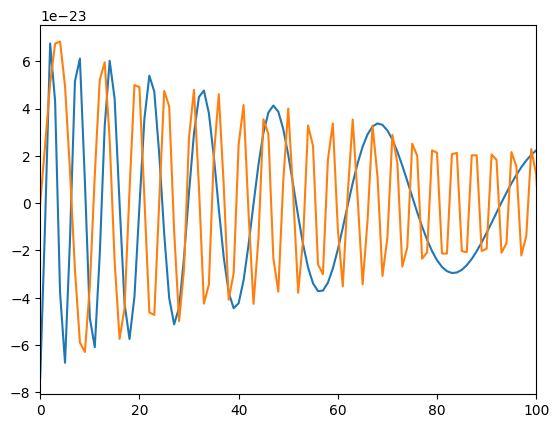

In [61]:
hp_ripple, _ = waveform_generate(theta_ripple)
plt.plot(hp_ripple)
plt.plot(hp_sage)
plt.xlim(0, 100)

## Comparing Sage waveform generation with LAL

In [ ]:
approximant = lalsim.SimInspiralGetApproximantFromString("IMRPhenomPv2")
m1_msun = 30.0 # In solar masses
m2_msun = 29.0
chi1 = 0.0
chi2 = 0.0
tc = 0.0 # Time of coalescence in seconds
phic = 0.0
dist_mpc = 440.0 # Distance to source in Mpc
inclination = 0.0 # Inclination Angle
m1_kg = m1_msun*lal.MSUN_SI
m2_kg = m2_msun*lal.MSUN_SI
distance = dist_mpc*1e6*lal.PC_SI

# Params for freq domain waveform
f_min = 20.0
f_max = 2048.0
f_ref = f_min
df = 0.25
sample_length_in_s = 1./df

hp, hc = lalsim.SimInspiralChooseFDWaveform(m1_kg, m2_kg,
                                            0., 0., chi1,
                                            0., 0., chi2,
                                            distance, inclination,
                                            phic, 0, 0., 0.,
                                            df, f_min, f_max, f_ref,
                                            None, approximant)
hp_lalsim = hp.data.data
hc_lalsim = hc.data.data

In [ ]:
plt.figure(figsize=(10.0, 4.0))
plt.plot(hp_lalsim)
plt.plot(hp_sage)
plt.xlabel('Samples')
plt.ylabel('Strain')
plt.xlim(0, 2000)
plt.show()